# Revenue Forecast em Python

Esta etapa conecta o Python ao banco PostgreSQL para consumir a view analítica `vw_forecast_base_monthly`, criada na camada SQL do projeto.

O objetivo é construir um fluxo de previsão de receita mensal, simulando um processo real de Revenue Planning: leitura de dados governados, preparação temporal, criação de baseline, modelagem preditiva, avaliação de erro e geração de uma base final de forecast.

## 1. Preparação do ambiente

Nesta etapa, são instaladas e importadas as bibliotecas necessárias para manipulação de dados, conexão com PostgreSQL, visualização e modelagem preditiva.

In [1]:
%pip install pandas numpy matplotlib scikit-learn sqlalchemy psycopg2-binary python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

## 2. Conexão com PostgreSQL e carga da base mensal

Nesta etapa, o Python se conecta ao banco `revenue_planning_db` e consome a view `vw_forecast_base_monthly`.

A view representa a base mensal consolidada de receita e será usada como fonte oficial para o forecast.

In [3]:
load_dotenv("../.env")

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = int(os.getenv("DB_PORT"))
DB_NAME = os.getenv("DB_NAME")

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(connection_url)

In [4]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT current_database();"))
    print("Banco conectado:", result.scalar())

Banco conectado: revenue_planning_db


## 3. Carga da base mensal de forecast

Nesta etapa, a view analítica `vw_forecast_base_monthly` é carregada do PostgreSQL para um DataFrame pandas.

Essa view representa a base mensal consolidada de receita e será usada como fonte oficial para a etapa de forecast.

A ordenação por `month_start` garante que a série temporal seja carregada em ordem cronológica, o que é essencial para análise temporal e modelagem preditiva.

In [5]:
df_forecast_base = pd.read_sql(
    """
    SELECT *
    FROM vw_forecast_base_monthly
    ORDER BY month_start;
    """,
    engine
)

## 4. Validação inicial da base carregada

Após carregar a view para o Python, é necessário validar se a base foi importada corretamente.

As validações desta etapa verificam:

- quantidade de linhas e colunas;
- primeiras linhas da base;
- tipos de dados;
- presença de valores nulos;
- período mínimo e máximo da série temporal;
- total de receita mensal;
- quantidade de meses disponíveis.

Essa checagem garante que a base mensal está consistente antes da preparação temporal e da modelagem.

In [6]:
# Dimensão da base
print("Dimensão da base:")
print(df_forecast_base.shape)

print("\n" + "-" * 50)

# Primeiras linhas
print("Primeiras linhas:")
display(df_forecast_base.head())

print("\n" + "-" * 50)

# Tipos de dados
print("Tipos de dados:")
display(df_forecast_base.dtypes)

print("\n" + "-" * 50)

# Valores nulos
print("Valores nulos por coluna:")
display(df_forecast_base.isna().sum())

print("\n" + "-" * 50)

# Período da série temporal
print("Período da série temporal:")
print("Início:", df_forecast_base["month_start"].min())
print("Fim:", df_forecast_base["month_start"].max())

print("\n" + "-" * 50)

# Quantidade de meses
print("Quantidade de meses:")
print(df_forecast_base["month_start"].nunique())

print("\n" + "-" * 50)

# Soma da receita mensal
print("Soma da receita mensal:")
print(df_forecast_base["monthly_revenue"].sum())

Dimensão da base:
(48, 12)

--------------------------------------------------
Primeiras linhas:


,month_start,year,month,year_month,monthly_revenue,monthly_profit,monthly_estimated_cost,monthly_quantity,avg_discount,orders_count,customers_count,monthly_profit_margin
0,2014-01-01,2014,1,2014-01,14236.90,2450.18,11786.72,284,0.126582,32,32,0.172101
1,2014-02-01,2014,2,2014-02,4519.92,862.30,3657.62,159,0.176087,28,27,0.190778
2,2014-03-01,2014,3,2014-03,55691.04,498.72,55192.32,585,0.167516,71,69,0.008955
3,2014-04-01,2014,4,2014-04,28295.35,3488.86,24806.49,536,0.110000,66,64,0.123302
4,2014-05-01,2014,5,2014-05,23648.28,2738.74,20909.54,466,0.155328,69,67,0.115811



--------------------------------------------------
Tipos de dados:


month_start                object
year                        int64
month                       int64
year_month                    str
monthly_revenue           float64
monthly_profit            float64
monthly_estimated_cost    float64
monthly_quantity            int64
avg_discount              float64
orders_count                int64
customers_count             int64
monthly_profit_margin     float64
dtype: object


--------------------------------------------------
Valores nulos por coluna:


month_start               0
year                      0
month                     0
year_month                0
monthly_revenue           0
monthly_profit            0
monthly_estimated_cost    0
monthly_quantity          0
avg_discount              0
orders_count              0
customers_count           0
monthly_profit_margin     0
dtype: int64


--------------------------------------------------
Período da série temporal:
Início: 2014-01-01
Fim: 2017-12-01

--------------------------------------------------
Quantidade de meses:
48

--------------------------------------------------
Soma da receita mensal:
2297201.0700000003


## 5. Preparação temporal para forecast

Nesta etapa, a base mensal carregada do PostgreSQL é preparada para análise temporal e modelagem preditiva.

A view `vw_forecast_base_monthly` já foi validada com 48 meses, sem valores nulos e com receita mensal consolidada. Agora, o objetivo é garantir que a coluna de data seja tratada corretamente pelo Python e que a série permaneça em ordem cronológica.

Essa preparação é necessária porque forecast depende da sequência temporal dos dados. Diferente de outros problemas de machine learning, aqui a ordem dos meses não pode ser embaralhada: o modelo deve aprender com o passado para avaliar períodos futuros.

Nesta etapa serão feitos apenas ajustes estruturais:

- criação de uma cópia da base original;
- conversão de `month_start` para tipo data;
- ordenação cronológica;
- validação da estrutura temporal.

Ainda não serão criados baseline, modelo preditivo ou divisão treino/teste.

In [7]:
df_forecast = df_forecast_base.copy()

df_forecast["month_start"] = pd.to_datetime(df_forecast["month_start"])

df_forecast = df_forecast.sort_values("month_start").reset_index(drop=True)

In [8]:
print("Tipo de month_start:")
print(df_forecast["month_start"].dtype)

print("\nPeríodo da série:")
print("Início:", df_forecast["month_start"].min())
print("Fim:", df_forecast["month_start"].max())

print("\nQuantidade de meses:")
print(df_forecast["month_start"].nunique())

print("\nBase ordenada cronologicamente:")
print(df_forecast["month_start"].is_monotonic_increasing)

expected_months = pd.date_range(
    start=df_forecast["month_start"].min(),
    end=df_forecast["month_start"].max(),
    freq="MS"
)

missing_months = expected_months.difference(df_forecast["month_start"])

print("\nMeses esperados:")
print(len(expected_months))

print("\nMeses existentes na base:")
print(df_forecast["month_start"].nunique())

print("\nMeses ausentes:")
print(len(missing_months))

if len(missing_months) > 0:
    display(missing_months)
else:
    print("Nenhum mês ausente na série.")

print("\nPrimeiras linhas:")
display(df_forecast.head())

print("\nÚltimas linhas:")
display(df_forecast.tail())

Tipo de month_start:
datetime64[s]

Período da série:
Início: 2014-01-01 00:00:00
Fim: 2017-12-01 00:00:00

Quantidade de meses:
48

Base ordenada cronologicamente:
True

Meses esperados:
48

Meses existentes na base:
48

Meses ausentes:
0
Nenhum mês ausente na série.

Primeiras linhas:


,month_start,year,month,year_month,monthly_revenue,monthly_profit,monthly_estimated_cost,monthly_quantity,avg_discount,orders_count,customers_count,monthly_profit_margin
0,2014-01-01,2014,1,2014-01,14236.90,2450.18,11786.72,284,0.126582,32,32,0.172101
1,2014-02-01,2014,2,2014-02,4519.92,862.30,3657.62,159,0.176087,28,27,0.190778
2,2014-03-01,2014,3,2014-03,55691.04,498.72,55192.32,585,0.167516,71,69,0.008955
3,2014-04-01,2014,4,2014-04,28295.35,3488.86,24806.49,536,0.110000,66,64,0.123302
4,2014-05-01,2014,5,2014-05,23648.28,2738.74,20909.54,466,0.155328,69,67,0.115811



Últimas linhas:


,month_start,year,month,year_month,monthly_revenue,monthly_profit,monthly_estimated_cost,monthly_quantity,avg_discount,orders_count,customers_count,monthly_profit_margin
43,2017-08-01,2017,8,2017-08,63120.85,9041.09,54079.76,884,0.143578,111,104,0.143235
44,2017-09-01,2017,9,2017-09,87866.66,10991.57,76875.09,1660,0.147386,226,196,0.125094
45,2017-10-01,2017,10,2017-10,77776.96,9275.38,68501.58,1133,0.174228,147,136,0.119256
46,2017-11-01,2017,11,2017-11,118447.81,9690.10,108757.71,1840,0.160980,261,216,0.081809
47,2017-12-01,2017,12,2017-12,83829.31,8483.40,75345.91,1723,0.146580,224,195,0.101198


### Visualização da série histórica de receita mensal

Com a série validada e ordenada cronologicamente, é possível visualizar o comportamento da receita ao longo do período analisado — identificando tendência de crescimento, variações sazonais e meses de maior volatilidade.

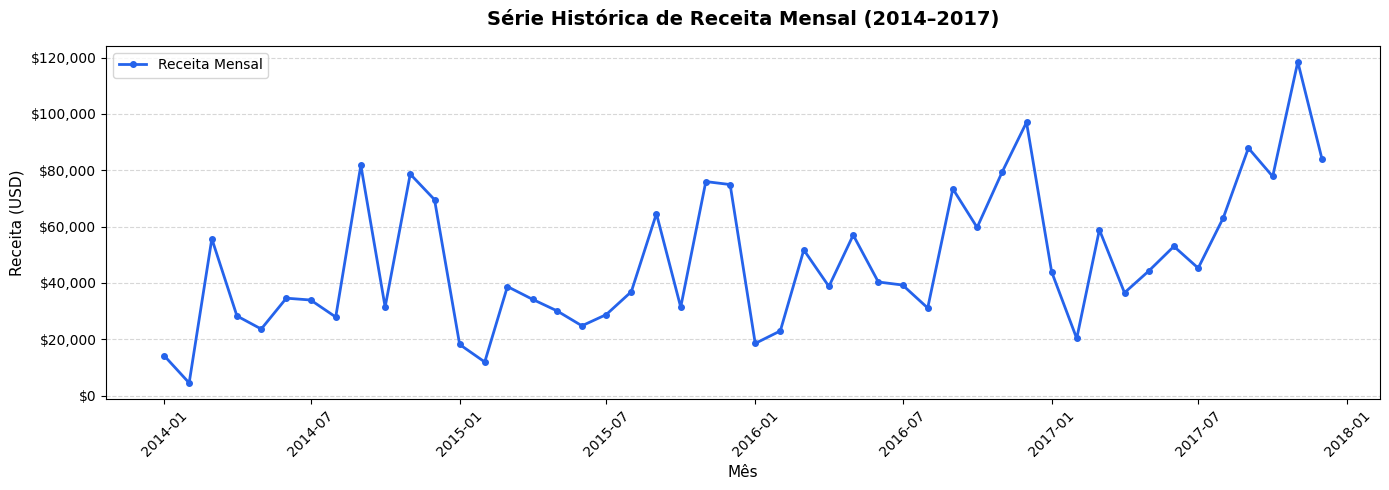

In [44]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_forecast["month_start"],
    df_forecast["monthly_revenue"],
    color="#2563EB",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Receita Mensal"
)

ax.set_title("Série Histórica de Receita Mensal (2014–2017)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Mês", fontsize=11)
ax.set_ylabel("Receita (USD)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Criação de variáveis temporais

Nesta etapa, são criadas variáveis derivadas da série mensal para apoiar a etapa de forecast.

As variáveis criadas representam tendência, sazonalidade e comportamento recente da receita:

- `time_index`: posição sequencial do mês na série;
- `quarter`: trimestre do ano;
- `is_year_end`: indicação de meses de fim de ano;
- `revenue_lag_1`: receita do mês anterior;
- `revenue_rolling_3`: média móvel da receita nos últimos 3 meses.

Essas variáveis ajudam a transformar a base mensal em uma estrutura mais adequada para comparação entre baseline e modelo preditivo.

In [9]:
df_forecast["time_index"] = range(1, len(df_forecast) + 1)

df_forecast["quarter"] = df_forecast["month_start"].dt.quarter

df_forecast["is_year_end"] = df_forecast["month"].isin([11, 12]).astype(int)

df_forecast["revenue_lag_1"] = df_forecast["monthly_revenue"].shift(1)

df_forecast["revenue_rolling_3"] = (
    df_forecast["monthly_revenue"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

In [10]:
print("Colunas criadas:")
display(
    df_forecast[
        [
            "month_start",
            "monthly_revenue",
            "time_index",
            "month",
            "quarter",
            "is_year_end",
            "revenue_lag_1",
            "revenue_rolling_3"
        ]
    ].head(10)
)

print("\nÚltimas linhas:")
display(
    df_forecast[
        [
            "month_start",
            "monthly_revenue",
            "time_index",
            "month",
            "quarter",
            "is_year_end",
            "revenue_lag_1",
            "revenue_rolling_3"
        ]
    ].tail(10)
)

print("\nValores nulos nas novas variáveis:")
display(
    df_forecast[
        [
            "time_index",
            "quarter",
            "is_year_end",
            "revenue_lag_1",
            "revenue_rolling_3"
        ]
    ].isna().sum()
)

print("\nResumo das novas variáveis:")
display(
    df_forecast[
        [
            "time_index",
            "quarter",
            "is_year_end",
            "revenue_lag_1",
            "revenue_rolling_3"
        ]
    ].describe()
)

Colunas criadas:


,month_start,monthly_revenue,time_index,month,quarter,is_year_end,revenue_lag_1,revenue_rolling_3
0,2014-01-01,14236.90,1,1,1,0,NaN,NaN
1,2014-02-01,4519.92,2,2,1,0,14236.90,NaN
2,2014-03-01,55691.04,3,3,1,0,4519.92,NaN
3,2014-04-01,28295.35,4,4,2,0,55691.04,24815.953333
4,2014-05-01,23648.28,5,5,2,0,28295.35,29502.103333
5,2014-06-01,34595.14,6,6,2,0,23648.28,35878.223333
6,2014-07-01,33946.37,7,7,3,0,34595.14,28846.256667
7,2014-08-01,27909.47,8,8,3,0,33946.37,30729.930000
8,2014-09-01,81777.34,9,9,3,0,27909.47,32150.326667
9,2014-10-01,31453.37,10,10,4,0,81777.34,47877.726667



Últimas linhas:


,month_start,monthly_revenue,time_index,month,quarter,is_year_end,revenue_lag_1,revenue_rolling_3
38,2017-03-01,58872.35,39,3,1,0,20301.12,53757.186667
39,2017-04-01,36521.52,40,4,2,0,58872.35,41048.280000
40,2017-05-01,44261.08,41,5,2,0,36521.52,38564.996667
41,2017-06-01,52981.73,42,6,2,0,44261.08,46551.650000
42,2017-07-01,45264.43,43,7,3,0,52981.73,44588.110000
43,2017-08-01,63120.85,44,8,3,0,45264.43,47502.413333
44,2017-09-01,87866.66,45,9,3,0,63120.85,53789.003333
45,2017-10-01,77776.96,46,10,4,0,87866.66,65417.313333
46,2017-11-01,118447.81,47,11,4,1,77776.96,76254.823333
47,2017-12-01,83829.31,48,12,4,1,118447.81,94697.143333



Valores nulos nas novas variáveis:


time_index           0
quarter              0
is_year_end          0
revenue_lag_1        1
revenue_rolling_3    3
dtype: int64


Resumo das novas variáveis:


,time_index,quarter,is_year_end,revenue_lag_1,revenue_rolling_3
count,48.00,48.000000,48.000000,47.000000,45.000000
mean,24.50,2.500000,0.166667,47093.016170,46610.733185
std,14.00,1.129865,0.376622,24897.927031,16104.806706
min,1.00,1.000000,0.000000,4519.920000,22950.580000
25%,12.75,1.750000,0.000000,29448.520000,33223.706667
50%,24.50,2.500000,0.000000,39261.990000,45360.776667
75%,36.25,3.250000,0.000000,63858.360000,55449.486667
max,48.00,4.000000,1.000000,118447.810000,94697.143333


## 7. Definição da base de modelagem

Nesta etapa, é criada a base que será usada nas fases de baseline e modelagem preditiva.

A base temporal `df_forecast` possui variáveis derivadas da receita, como `revenue_lag_1` e `revenue_rolling_3`. Essas variáveis geram valores nulos nos primeiros meses da série, pois ainda não existe histórico anterior suficiente para calculá-las.

Para evitar treinar modelos com dados incompletos, será criada uma nova base chamada `df_model`, contendo apenas os registros com todas as variáveis necessárias preenchidas.

A variável alvo do forecast será `monthly_revenue`, que representa a receita mensal realizada.

Nesta etapa ainda não será feita a divisão treino/teste, baseline ou modelagem. O objetivo é apenas definir a base final de entrada para essas próximas fases.

In [11]:
target = "monthly_revenue"

feature_columns = [
    "time_index",
    "month",
    "quarter",
    "is_year_end",
    "revenue_lag_1",
    "revenue_rolling_3"
]

df_model = df_forecast.dropna(subset=feature_columns).copy()

X = df_model[feature_columns]
y = df_model[target]

In [12]:
print("Dimensão da base original preparada:")
print(df_forecast.shape)

print("\nDimensão da base de modelagem:")
print(df_model.shape)

print("\nVariável alvo:")
print(target)

print("\nFeatures selecionadas:")
display(feature_columns)

print("\nValores nulos nas features:")
display(df_model[feature_columns].isna().sum())

print("\nValores nulos no target:")
print(df_model[target].isna().sum())

print("\nPeríodo da base de modelagem:")
print("Início:", df_model["month_start"].min())
print("Fim:", df_model["month_start"].max())

print("\nPrimeiras linhas da base de modelagem:")
display(
    df_model[
        ["month_start", target] + feature_columns
    ].head()
)

print("\nÚltimas linhas da base de modelagem:")
display(
    df_model[
        ["month_start", target] + feature_columns
    ].tail()
)

Dimensão da base original preparada:
(48, 17)

Dimensão da base de modelagem:
(45, 17)

Variável alvo:
monthly_revenue

Features selecionadas:


['time_index',
 'month',
 'quarter',
 'is_year_end',
 'revenue_lag_1',
 'revenue_rolling_3']


Valores nulos nas features:


time_index           0
month                0
quarter              0
is_year_end          0
revenue_lag_1        0
revenue_rolling_3    0
dtype: int64


Valores nulos no target:
0

Período da base de modelagem:
Início: 2014-04-01 00:00:00
Fim: 2017-12-01 00:00:00

Primeiras linhas da base de modelagem:


,month_start,monthly_revenue,time_index,month,quarter,is_year_end,revenue_lag_1,revenue_rolling_3
3,2014-04-01,28295.35,4,4,2,0,55691.04,24815.953333
4,2014-05-01,23648.28,5,5,2,0,28295.35,29502.103333
5,2014-06-01,34595.14,6,6,2,0,23648.28,35878.223333
6,2014-07-01,33946.37,7,7,3,0,34595.14,28846.256667
7,2014-08-01,27909.47,8,8,3,0,33946.37,30729.930000



Últimas linhas da base de modelagem:


,month_start,monthly_revenue,time_index,month,quarter,is_year_end,revenue_lag_1,revenue_rolling_3
43,2017-08-01,63120.85,44,8,3,0,45264.43,47502.413333
44,2017-09-01,87866.66,45,9,3,0,63120.85,53789.003333
45,2017-10-01,77776.96,46,10,4,0,87866.66,65417.313333
46,2017-11-01,118447.81,47,11,4,1,77776.96,76254.823333
47,2017-12-01,83829.31,48,12,4,1,118447.81,94697.143333


## 8. Separação treino/teste temporal

Nesta etapa, a base de modelagem é separada em treino e teste respeitando a ordem cronológica dos dados.

Como o objetivo é forecast de receita mensal, não será utilizado split aleatório. O modelo deve aprender com períodos passados e ser avaliado em períodos futuros.

A divisão adotada será:

- treino: meses anteriores a 2017;
- teste: meses de 2017.

Essa abordagem simula um cenário real de Revenue Planning, em que o histórico disponível até o fim de 2016 é usado para avaliar a capacidade de previsão sobre os meses de 2017.

In [13]:
train = df_model[df_model["year"] < 2017].copy()
test = df_model[df_model["year"] == 2017].copy()

X_train = train[feature_columns]
y_train = train[target]

X_test = test[feature_columns]
y_test = test[target]

In [14]:
print("Dimensão treino:")
print(train.shape)

print("\nDimensão teste:")
print(test.shape)

print("\nPeríodo treino:")
print("Início:", train["month_start"].min())
print("Fim:", train["month_start"].max())

print("\nPeríodo teste:")
print("Início:", test["month_start"].min())
print("Fim:", test["month_start"].max())

print("\nQuantidade de meses treino:")
print(train["month_start"].nunique())

print("\nQuantidade de meses teste:")
print(test["month_start"].nunique())

print("\nShapes X/y:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Dimensão treino:
(33, 17)

Dimensão teste:
(12, 17)

Período treino:
Início: 2014-04-01 00:00:00
Fim: 2016-12-01 00:00:00

Período teste:
Início: 2017-01-01 00:00:00
Fim: 2017-12-01 00:00:00

Quantidade de meses treino:
33

Quantidade de meses teste:
12

Shapes X/y:
X_train: (33, 6)
y_train: (33,)
X_test: (12, 6)
y_test: (12,)


## 9. Baseline de forecast

Nesta etapa, é criado um baseline para previsão de receita mensal.

O baseline representa uma regra simples de comparação antes da criação de um modelo preditivo. Ele é importante porque permite avaliar se um modelo de machine learning realmente melhora uma abordagem simples e interpretável.

A estratégia adotada será usar a média móvel dos 3 meses anteriores como previsão baseline.

Essa escolha é adequada porque:

- utiliza apenas informações passadas;
- evita vazamento de informação;
- é simples de explicar;
- cria uma referência mínima para comparação com o modelo preditivo.

Nesta etapa, o baseline será aplicado ao conjunto de teste, que representa os meses de 2017.

In [15]:
baseline_results = test[["month_start", "monthly_revenue", "revenue_rolling_3"]].copy()

baseline_results = baseline_results.rename(
    columns={
        "monthly_revenue": "actual_revenue",
        "revenue_rolling_3": "predicted_revenue"
    }
)

baseline_results["model_name"] = "baseline_rolling_3"

In [16]:
baseline_results["revenue_error"] = (
    baseline_results["actual_revenue"] - baseline_results["predicted_revenue"]
)

baseline_results["absolute_error"] = baseline_results["revenue_error"].abs()

baseline_results["absolute_percentage_error"] = (
    baseline_results["absolute_error"] / baseline_results["actual_revenue"]
)

In [17]:
baseline_mae = mean_absolute_error(
    baseline_results["actual_revenue"],
    baseline_results["predicted_revenue"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_results["actual_revenue"],
        baseline_results["predicted_revenue"]
    )
)

baseline_mape = baseline_results["absolute_percentage_error"].mean()

print("Baseline - Média móvel 3 meses")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape)

Baseline - Média móvel 3 meses
MAE: 18787.411111111116
RMSE: 25181.42921263616
MAPE: 0.4303520892893467


In [18]:
display(baseline_results)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error
36,2017-01-01,43971.37,78699.633333,baseline_rolling_3,-34728.263333,34728.263333,0.789793
37,2017-02-01,20301.12,73460.823333,baseline_rolling_3,-53159.703333,53159.703333,2.618560
38,2017-03-01,58872.35,53757.186667,baseline_rolling_3,5115.163333,5115.163333,0.086886
39,2017-04-01,36521.52,41048.280000,baseline_rolling_3,-4526.760000,4526.760000,0.123948
40,2017-05-01,44261.08,38564.996667,baseline_rolling_3,5696.083333,5696.083333,0.128693
41,2017-06-01,52981.73,46551.650000,baseline_rolling_3,6430.080000,6430.080000,0.121364
42,2017-07-01,45264.43,44588.110000,baseline_rolling_3,676.320000,676.320000,0.014942
43,2017-08-01,63120.85,47502.413333,baseline_rolling_3,15618.436667,15618.436667,0.247437
44,2017-09-01,87866.66,53789.003333,baseline_rolling_3,34077.656667,34077.656667,0.387834
45,2017-10-01,77776.96,65417.313333,baseline_rolling_3,12359.646667,12359.646667,0.158911


## 10. Modelo preditivo com regressão linear

Nesta etapa, será treinado um primeiro modelo preditivo para estimar a receita mensal.

Como a base possui apenas 45 observações disponíveis para modelagem, a escolha inicial será uma regressão linear. O objetivo não é criar um modelo complexo, mas sim construir uma referência preditiva simples, interpretável e comparável ao baseline.

O modelo será treinado com os meses anteriores a 2017 e avaliado nos meses de 2017, respeitando a separação temporal definida anteriormente.

As features utilizadas serão:

- `time_index`;
- `month`;
- `quarter`;
- `is_year_end`;
- `revenue_lag_1`;
- `revenue_rolling_3`.

A variável alvo será `monthly_revenue`.

In [19]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
linear_predictions = linear_model.predict(X_test)

linear_results = test[["month_start", "monthly_revenue"]].copy()

linear_results = linear_results.rename(
    columns={
        "monthly_revenue": "actual_revenue"
    }
)

linear_results["predicted_revenue"] = linear_predictions
linear_results["model_name"] = "linear_regression"

In [21]:
linear_results["revenue_error"] = (
    linear_results["actual_revenue"] - linear_results["predicted_revenue"]
)

linear_results["absolute_error"] = linear_results["revenue_error"].abs()

linear_results["absolute_percentage_error"] = (
    linear_results["absolute_error"] / linear_results["actual_revenue"]
)

In [22]:
linear_mae = mean_absolute_error(
    linear_results["actual_revenue"],
    linear_results["predicted_revenue"]
)

linear_rmse = np.sqrt(
    mean_squared_error(
        linear_results["actual_revenue"],
        linear_results["predicted_revenue"]
    )
)

linear_mape = linear_results["absolute_percentage_error"].mean()

print("Modelo - Regressão Linear")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("MAPE:", linear_mape)

Modelo - Regressão Linear
MAE: 13640.82169452098
RMSE: 17519.204964954606
MAPE: 0.2211268060154822


In [23]:
display(linear_results)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error
36,2017-01-01,43971.37,18746.473652,linear_regression,25224.896348,25224.896348,0.573666
37,2017-02-01,20301.12,26736.732693,linear_regression,-6435.612693,6435.612693,0.317008
38,2017-03-01,58872.35,44364.775069,linear_regression,14507.574931,14507.574931,0.246424
39,2017-04-01,36521.52,41068.229284,linear_regression,-4546.709284,4546.709284,0.124494
40,2017-05-01,44261.08,50755.108514,linear_regression,-6494.028514,6494.028514,0.146721
41,2017-06-01,52981.73,58466.416260,linear_regression,-5484.686260,5484.686260,0.103520
42,2017-07-01,45264.43,47227.042344,linear_regression,-1962.612344,1962.612344,0.043359
43,2017-08-01,63120.85,55809.835111,linear_regression,7311.014889,7311.014889,0.115826
44,2017-09-01,87866.66,65303.185226,linear_regression,22563.474774,22563.474774,0.256792
45,2017-10-01,77776.96,49255.333701,linear_regression,28521.626299,28521.626299,0.366710


## 11. Comparação entre baseline e modelo preditivo

Nesta etapa, os resultados do baseline e da regressão linear são comparados.

O objetivo é avaliar se o modelo preditivo melhora uma regra simples de previsão baseada na média móvel dos 3 meses anteriores.

A comparação será feita com três métricas:

- MAE: erro médio absoluto;
- RMSE: erro quadrático médio, penalizando erros maiores;
- MAPE: erro percentual absoluto médio.

Essa comparação permite identificar se o modelo agrega valor em relação ao baseline.

In [24]:
metrics_comparison = pd.DataFrame(
    {
        "model_name": ["baseline_rolling_3", "linear_regression"],
        "mae": [baseline_mae, linear_mae],
        "rmse": [baseline_rmse, linear_rmse],
        "mape": [baseline_mape, linear_mape]
    }
)

metrics_comparison

,model_name,mae,rmse,mape
0,baseline_rolling_3,18787.411111,25181.429213,0.430352
1,linear_regression,13640.821695,17519.204965,0.221127


In [25]:
best_model = metrics_comparison.sort_values("mae").iloc[0]

print("Melhor modelo pelo MAE:")
print(best_model["model_name"])

print("\nMAE:")
print(best_model["mae"])

print("\nRMSE:")
print(best_model["rmse"])

print("\nMAPE:")
print(best_model["mape"])

Melhor modelo pelo MAE:
linear_regression

MAE:
13640.82169452098

RMSE:
17519.204964954606

MAPE:
0.2211268060154822


In [26]:
mae_improvement_pct = (
    (baseline_mae - linear_mae) / baseline_mae
)

rmse_improvement_pct = (
    (baseline_rmse - linear_rmse) / baseline_rmse
)

mape_improvement_pct = (
    (baseline_mape - linear_mape) / baseline_mape
)

print("Melhoria percentual da regressão linear vs baseline")
print("MAE:", mae_improvement_pct)
print("RMSE:", rmse_improvement_pct)
print("MAPE:", mape_improvement_pct)

Melhoria percentual da regressão linear vs baseline
MAE: 0.2739381911724057
RMSE: 0.30428075320826564
MAPE: 0.48617234232408274


## 12. Análise de erros e desvios

Nesta etapa, os resultados do modelo preditivo são analisados em maior detalhe.

Além das métricas agregadas, como MAE, RMSE e MAPE, é importante entender em quais meses o modelo errou mais, se a previsão ficou acima ou abaixo da receita realizada e quais períodos apresentaram maior desvio.

Essa análise aproxima o forecast de uma lógica de Revenue Planning, pois permite avaliar não apenas a performance média do modelo, mas também os meses em que houve maior diferença entre receita prevista e receita realizada.

A análise será feita a partir dos resultados da regressão linear, que apresentou melhor desempenho em relação ao baseline.

In [27]:
linear_results["error_direction"] = np.where(
    linear_results["revenue_error"] > 0,
    "underestimated",
    "overestimated"
)

linear_results["error_direction_pt"] = np.where(
    linear_results["revenue_error"] > 0,
    "subestimou receita",
    "superestimou receita"
)

display(linear_results)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
36,2017-01-01,43971.37,18746.473652,linear_regression,25224.896348,25224.896348,0.573666,underestimated,subestimou receita
37,2017-02-01,20301.12,26736.732693,linear_regression,-6435.612693,6435.612693,0.317008,overestimated,superestimou receita
38,2017-03-01,58872.35,44364.775069,linear_regression,14507.574931,14507.574931,0.246424,underestimated,subestimou receita
39,2017-04-01,36521.52,41068.229284,linear_regression,-4546.709284,4546.709284,0.124494,overestimated,superestimou receita
40,2017-05-01,44261.08,50755.108514,linear_regression,-6494.028514,6494.028514,0.146721,overestimated,superestimou receita
41,2017-06-01,52981.73,58466.416260,linear_regression,-5484.686260,5484.686260,0.103520,overestimated,superestimou receita
42,2017-07-01,45264.43,47227.042344,linear_regression,-1962.612344,1962.612344,0.043359,overestimated,superestimou receita
43,2017-08-01,63120.85,55809.835111,linear_regression,7311.014889,7311.014889,0.115826,underestimated,subestimou receita
44,2017-09-01,87866.66,65303.185226,linear_regression,22563.474774,22563.474774,0.256792,underestimated,subestimou receita
45,2017-10-01,77776.96,49255.333701,linear_regression,28521.626299,28521.626299,0.366710,underestimated,subestimou receita


In [28]:
largest_absolute_errors = (
    linear_results
    .sort_values("absolute_error", ascending=False)
    .head(5)
)

display(largest_absolute_errors)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
46,2017-11-01,118447.81,82375.316991,linear_regression,36072.493009,36072.493009,0.304543,underestimated,subestimou receita
45,2017-10-01,77776.96,49255.333701,linear_regression,28521.626299,28521.626299,0.366710,underestimated,subestimou receita
36,2017-01-01,43971.37,18746.473652,linear_regression,25224.896348,25224.896348,0.573666,underestimated,subestimou receita
44,2017-09-01,87866.66,65303.185226,linear_regression,22563.474774,22563.474774,0.256792,underestimated,subestimou receita
38,2017-03-01,58872.35,44364.775069,linear_regression,14507.574931,14507.574931,0.246424,underestimated,subestimou receita


In [29]:
largest_percentage_errors = (
    linear_results
    .sort_values("absolute_percentage_error", ascending=False)
    .head(5)
)

display(largest_percentage_errors)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
36,2017-01-01,43971.37,18746.473652,linear_regression,25224.896348,25224.896348,0.573666,underestimated,subestimou receita
45,2017-10-01,77776.96,49255.333701,linear_regression,28521.626299,28521.626299,0.366710,underestimated,subestimou receita
37,2017-02-01,20301.12,26736.732693,linear_regression,-6435.612693,6435.612693,0.317008,overestimated,superestimou receita
46,2017-11-01,118447.81,82375.316991,linear_regression,36072.493009,36072.493009,0.304543,underestimated,subestimou receita
44,2017-09-01,87866.66,65303.185226,linear_regression,22563.474774,22563.474774,0.256792,underestimated,subestimou receita


In [30]:
error_direction_summary = (
    linear_results
    .groupby("error_direction_pt")
    .agg(
        months_count=("month_start", "count"),
        total_error=("revenue_error", "sum"),
        avg_absolute_error=("absolute_error", "mean"),
        avg_percentage_error=("absolute_percentage_error", "mean")
    )
    .reset_index()
)

display(error_direction_summary)

,error_direction_pt,months_count,total_error,avg_absolute_error,avg_percentage_error
0,subestimou receita,6,134201.080249,22366.846708,0.310660
1,superestimou receita,6,-29488.780085,4914.796681,0.131593


## 13. Teste de modelos alternativos

A regressão linear apresentou desempenho superior ao baseline, mas ainda manteve erro relevante e tendência de subestimar meses de maior receita.

Por isso, antes de consolidar uma base final de forecast, serão testados modelos alternativos simples e defensáveis.

O objetivo desta etapa é avaliar se outro modelo consegue reduzir o erro mantendo uma abordagem coerente para uma base mensal pequena.

Serão comparados:

- baseline com média móvel de 3 meses;
- regressão linear;
- ridge regression;
- random forest regressor;
- gradient boosting regressor.

A comparação será feita com MAE, RMSE e MAPE no conjunto de teste de 2017.

In [31]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

candidate_models = {
    "linear_regression": LinearRegression(),
    "ridge_regression": Ridge(alpha=1.0),
    "random_forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        random_state=42
    ),
    "gradient_boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

model_results_list = []
model_metrics_list = []

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results = test[["month_start", "monthly_revenue"]].copy()

    results = results.rename(
        columns={
            "monthly_revenue": "actual_revenue"
        }
    )

    results["predicted_revenue"] = predictions
    results["model_name"] = model_name

    results["revenue_error"] = (
        results["actual_revenue"] - results["predicted_revenue"]
    )

    results["absolute_error"] = results["revenue_error"].abs()

    results["absolute_percentage_error"] = (
        results["absolute_error"] / results["actual_revenue"]
    )

    results["error_direction"] = np.where(
        results["revenue_error"] > 0,
        "underestimated",
        "overestimated"
    )

    results["error_direction_pt"] = np.where(
        results["revenue_error"] > 0,
        "subestimou receita",
        "superestimou receita"
    )

    mae = mean_absolute_error(
        results["actual_revenue"],
        results["predicted_revenue"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            results["actual_revenue"],
            results["predicted_revenue"]
        )
    )

    mape = results["absolute_percentage_error"].mean()

    model_results_list.append(results)

    model_metrics_list.append(
        {
            "model_name": model_name,
            "mae": mae,
            "rmse": rmse,
            "mape": mape
        }
    )

all_model_results = pd.concat(model_results_list, ignore_index=True)

model_metrics_alternatives = pd.DataFrame(model_metrics_list)

model_metrics_comparison_full = pd.concat(
    [
        metrics_comparison,
        model_metrics_alternatives[
            ~model_metrics_alternatives["model_name"].isin(
                metrics_comparison["model_name"]
            )
        ]
    ],
    ignore_index=True
)

model_metrics_comparison_full = (
    model_metrics_comparison_full
    .sort_values("mae")
    .reset_index(drop=True)
)

display(model_metrics_comparison_full)

,model_name,mae,rmse,mape
0,ridge_regression,12747.087964,16406.984319,0.219440
1,linear_regression,13640.821695,17519.204965,0.221127
2,random_forest,15286.717236,18081.567763,0.264703
3,gradient_boosting,15296.519301,18067.893597,0.282837
4,baseline_rolling_3,18787.411111,25181.429213,0.430352


### Comparação de MAE por modelo

A comparação visual do MAE entre os modelos testados evidencia a superioridade da Ridge Regression sobre os demais candidatos e sobre o baseline.

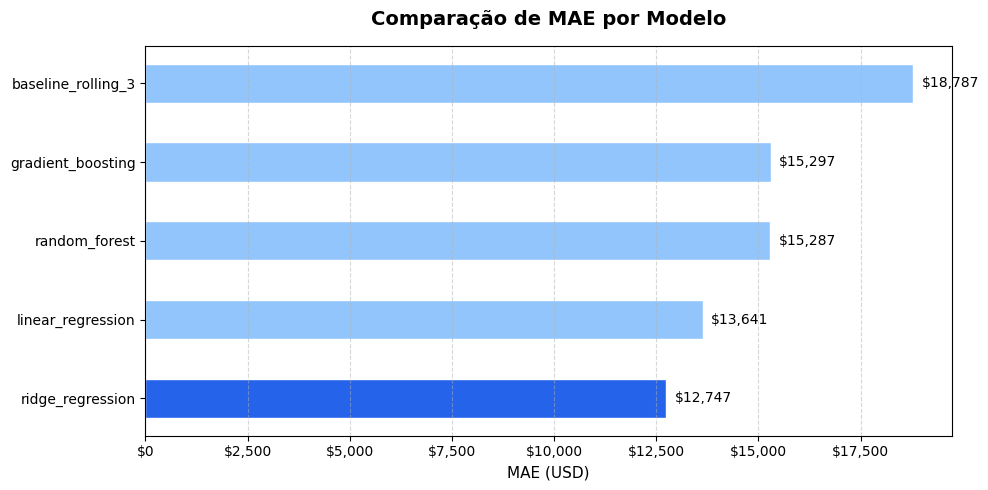

In [45]:
metrics_plot = model_metrics_comparison_full.sort_values("mae", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    metrics_plot["model_name"],
    metrics_plot["mae"],
    color=["#2563EB" if m == "ridge_regression" else "#93C5FD" for m in metrics_plot["model_name"]],
    edgecolor="white",
    height=0.5
)

for bar, value in zip(bars, metrics_plot["mae"]):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        fontsize=10
    )

ax.set_title("Comparação de MAE por Modelo", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("MAE (USD)", fontsize=11)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 14. Análise detalhada do melhor modelo: Ridge Regression

Após a comparação dos modelos, a Ridge Regression apresentou o melhor desempenho geral pelas métricas MAE, RMSE e MAPE.

Nesta etapa, o objetivo é analisar o comportamento do modelo no teste de 2017, verificando:

- maiores erros absolutos;
- maiores erros percentuais;
- meses subestimados;
- meses superestimados.

Essa análise ajuda a entender se o modelo é consistente mês a mês e quais limitações devem ser consideradas antes da consolidação final.

In [32]:
ridge_results = all_model_results[
    all_model_results["model_name"] == "ridge_regression"
].copy()

display(ridge_results)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
12,2017-01-01,43971.37,20576.039205,ridge_regression,23395.330795,23395.330795,0.532058,underestimated,subestimou receita
13,2017-02-01,20301.12,30650.662829,ridge_regression,-10349.542829,10349.542829,0.509802,overestimated,superestimou receita
14,2017-03-01,58872.35,43758.553351,ridge_regression,15113.796649,15113.796649,0.256721,underestimated,subestimou receita
15,2017-04-01,36521.52,40337.929733,ridge_regression,-3816.409733,3816.409733,0.104498,overestimated,superestimou receita
16,2017-05-01,44261.08,49605.528227,ridge_regression,-5344.448227,5344.448227,0.120748,overestimated,superestimou receita
17,2017-06-01,52981.73,56353.160691,ridge_regression,-3371.430691,3371.430691,0.063634,overestimated,superestimou receita
18,2017-07-01,45264.43,50730.058161,ridge_regression,-5465.628161,5465.628161,0.120749,overestimated,superestimou receita
19,2017-08-01,63120.85,58704.088421,ridge_regression,4416.761579,4416.761579,0.069973,underestimated,subestimou receita
20,2017-09-01,87866.66,65766.096866,ridge_regression,22100.563134,22100.563134,0.251524,underestimated,subestimou receita
21,2017-10-01,77776.96,57017.205962,ridge_regression,20759.754038,20759.754038,0.266914,underestimated,subestimou receita


### Realizado vs Previsto — Ridge Regression (2017)

A comparação mês a mês entre receita realizada e prevista permite identificar onde o modelo acompanhou bem a tendência e onde subestimou períodos de maior receita.

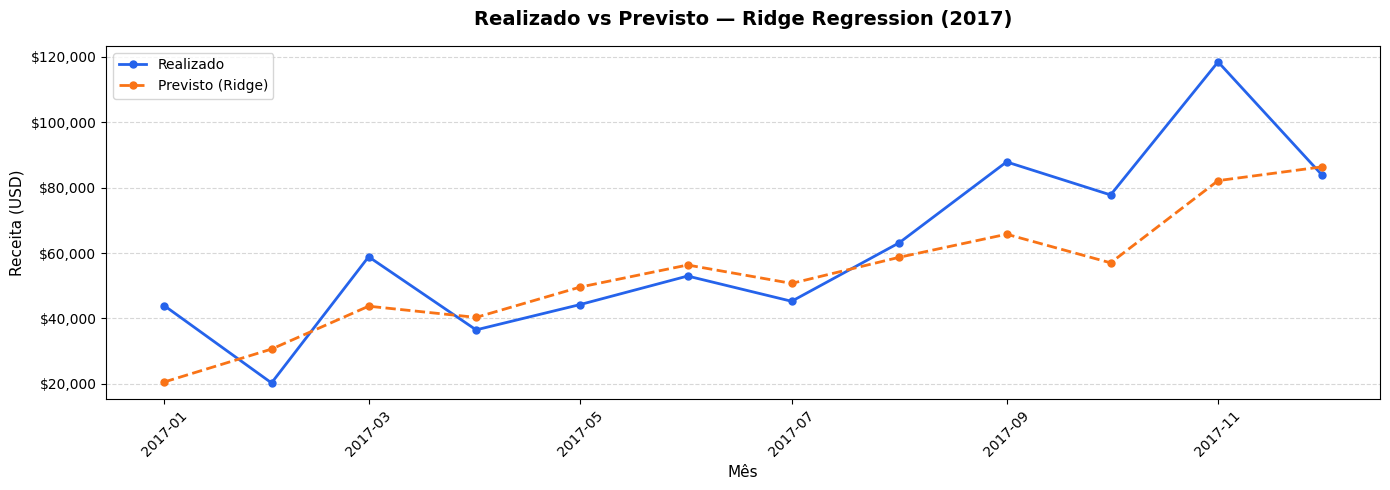

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    ridge_results["month_start"],
    ridge_results["actual_revenue"],
    color="#2563EB",
    linewidth=2,
    marker="o",
    markersize=5,
    label="Realizado"
)

ax.plot(
    ridge_results["month_start"],
    ridge_results["predicted_revenue"],
    color="#F97316",
    linewidth=2,
    marker="o",
    markersize=5,
    linestyle="--",
    label="Previsto (Ridge)"
)

ax.set_title("Realizado vs Previsto — Ridge Regression (2017)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Mês", fontsize=11)
ax.set_ylabel("Receita (USD)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
ridge_largest_absolute_errors = (
    ridge_results
    .sort_values("absolute_error", ascending=False)
    .head(5)
)

display(ridge_largest_absolute_errors)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
22,2017-11-01,118447.81,82147.625174,ridge_regression,36300.184826,36300.184826,0.306466,underestimated,subestimou receita
12,2017-01-01,43971.37,20576.039205,ridge_regression,23395.330795,23395.330795,0.532058,underestimated,subestimou receita
20,2017-09-01,87866.66,65766.096866,ridge_regression,22100.563134,22100.563134,0.251524,underestimated,subestimou receita
21,2017-10-01,77776.96,57017.205962,ridge_regression,20759.754038,20759.754038,0.266914,underestimated,subestimou receita
14,2017-03-01,58872.35,43758.553351,ridge_regression,15113.796649,15113.796649,0.256721,underestimated,subestimou receita


In [34]:
ridge_largest_percentage_errors = (
    ridge_results
    .sort_values("absolute_percentage_error", ascending=False)
    .head(5)
)

display(ridge_largest_percentage_errors)

,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
12,2017-01-01,43971.37,20576.039205,ridge_regression,23395.330795,23395.330795,0.532058,underestimated,subestimou receita
13,2017-02-01,20301.12,30650.662829,ridge_regression,-10349.542829,10349.542829,0.509802,overestimated,superestimou receita
22,2017-11-01,118447.81,82147.625174,ridge_regression,36300.184826,36300.184826,0.306466,underestimated,subestimou receita
21,2017-10-01,77776.96,57017.205962,ridge_regression,20759.754038,20759.754038,0.266914,underestimated,subestimou receita
14,2017-03-01,58872.35,43758.553351,ridge_regression,15113.796649,15113.796649,0.256721,underestimated,subestimou receita


In [35]:
ridge_error_direction_summary = (
    ridge_results
    .groupby("error_direction_pt")
    .agg(
        months_count=("month_start", "count"),
        total_error=("revenue_error", "sum"),
        avg_absolute_error=("absolute_error", "mean"),
        avg_percentage_error=("absolute_percentage_error", "mean")
    )
    .reset_index()
)

display(ridge_error_direction_summary)

,error_direction_pt,months_count,total_error,avg_absolute_error,avg_percentage_error
0,subestimou receita,6,122086.391021,20347.731837,0.280609
1,superestimou receita,6,-30878.664553,5146.444092,0.158271


### Erro absoluto por mês — direção do desvio

A análise do erro absoluto mês a mês evidencia os períodos de maior desvio e a direção predominante — subestimação nos meses de pico de receita.

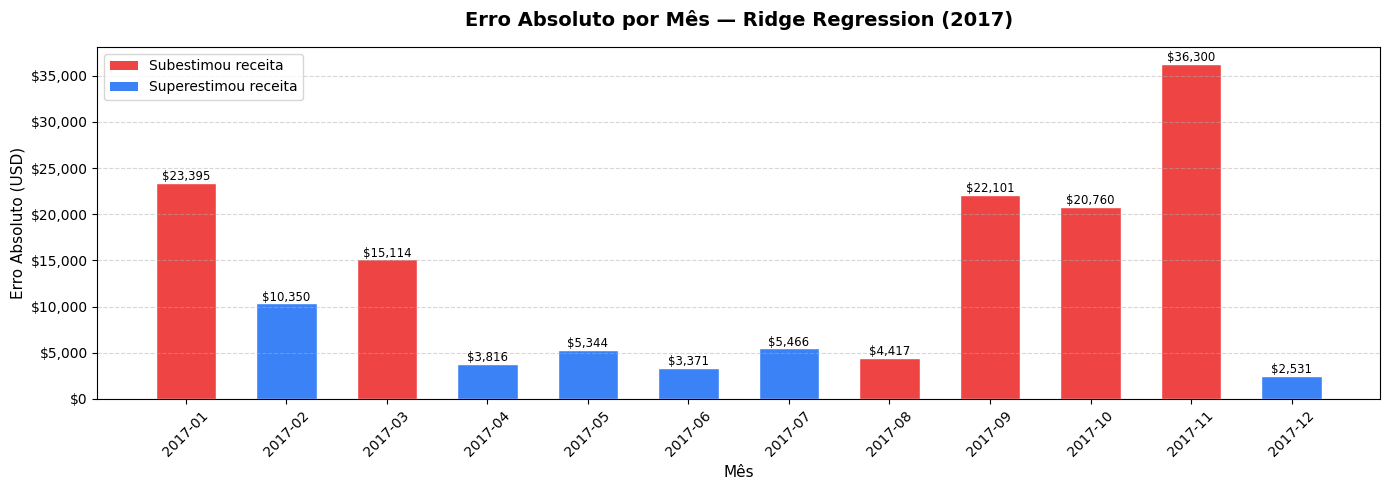

In [47]:
colors = ["#EF4444" if d == "underestimated" else "#3B82F6" for d in ridge_results["error_direction"]]

fig, ax = plt.subplots(figsize=(14, 5))

bars = ax.bar(
    ridge_results["month_start"].dt.strftime("%Y-%m"),
    ridge_results["absolute_error"],
    color=colors,
    edgecolor="white",
    width=0.6
)

for bar, value in zip(bars, ridge_results["absolute_error"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"${value:,.0f}",
        ha="center",
        fontsize=8.5
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#EF4444", label="Subestimou receita"),
    Patch(facecolor="#3B82F6", label="Superestimou receita")
]
ax.legend(handles=legend_elements)

ax.set_title("Erro Absoluto por Mês — Ridge Regression (2017)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Mês", fontsize=11)
ax.set_ylabel("Erro Absoluto (USD)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretação

A Ridge Regression confirmou ser o melhor modelo entre os candidatos testados, com MAE de $12.747, RMSE de $16.407 e MAPE de 21,94% — superando o baseline de média móvel em todas as métricas e apresentando melhor estabilidade que Random Forest e Gradient Boosting em uma base mensal pequena.

A análise visual do realizado vs previsto mostra que o modelo acompanha bem a tendência geral de crescimento ao longo de 2017, mas perde os picos de receita. Os meses de janeiro, março, setembro, outubro e novembro concentram os maiores erros absolutos — todos casos de subestimação, com erro máximo de $36.300 em novembro.

O padrão é consistente: os 6 meses subestimados geraram erro médio de $20.348, enquanto os 6 meses superestimados geraram erro médio de $5.146. O modelo é conservador — erra pouco para cima e muito para baixo quando a receita cresce acima da tendência recente.

Essa limitação é esperada dado o volume da base: 33 meses de treino, sem variáveis comerciais externas como campanhas, canal ou sazonalidade estruturada. O modelo captura tendência e comportamento recente, mas não tem informação suficiente para antecipar acelerações de receita.

O forecast desta versão é adequado para planejamento macro e análise de tendência. Para uso operacional de alta precisão, seria necessário ampliar o histórico e incorporar variáveis de negócio como pipeline comercial, metas e calendário de campanhas.

## 15. Fechamento do modelo final

A Ridge Regression foi selecionada como o melhor modelo desta versão do forecast, pois apresentou o menor MAE, RMSE e MAPE entre os modelos testados.

Apesar do melhor desempenho, o modelo ainda apresenta limitação relevante: tende a subestimar meses de maior receita. Isso indica que o forecast deve ser interpretado como apoio ao planejamento macro e análise de tendência, não como previsão operacional de alta precisão.

A escolha da Ridge é adequada para esta versão porque o modelo superou o baseline, manteve baixa complexidade e apresentou melhor estabilidade em uma base mensal pequena.

A próxima etapa será exportar as bases finais para integração com o Power BI.

In [36]:
final_model_name = "ridge_regression"

final_model_metrics = model_metrics_comparison_full[
    model_metrics_comparison_full["model_name"] == final_model_name
].copy()

final_forecast_results = ridge_results.copy()

display(final_model_metrics)
display(final_forecast_results.head())

,model_name,mae,rmse,mape
0,ridge_regression,12747.087964,16406.984319,0.21944


,month_start,actual_revenue,predicted_revenue,model_name,revenue_error,absolute_error,absolute_percentage_error,error_direction,error_direction_pt
12,2017-01-01,43971.37,20576.039205,ridge_regression,23395.330795,23395.330795,0.532058,underestimated,subestimou receita
13,2017-02-01,20301.12,30650.662829,ridge_regression,-10349.542829,10349.542829,0.509802,overestimated,superestimou receita
14,2017-03-01,58872.35,43758.553351,ridge_regression,15113.796649,15113.796649,0.256721,underestimated,subestimou receita
15,2017-04-01,36521.52,40337.929733,ridge_regression,-3816.409733,3816.409733,0.104498,overestimated,superestimou receita
16,2017-05-01,44261.08,49605.528227,ridge_regression,-5344.448227,5344.448227,0.120748,overestimated,superestimou receita


In [37]:
print("Modelo final selecionado:")
print(final_model_name)

print("\nMétricas do modelo final:")
display(final_model_metrics)

print("\nDimensão da base final de forecast:")
print(final_forecast_results.shape)

print("\nPeríodo do forecast:")
print("Início:", final_forecast_results["month_start"].min())
print("Fim:", final_forecast_results["month_start"].max())

print("\nValores nulos:")
display(final_forecast_results.isna().sum())

Modelo final selecionado:
ridge_regression

Métricas do modelo final:


,model_name,mae,rmse,mape
0,ridge_regression,12747.087964,16406.984319,0.21944



Dimensão da base final de forecast:
(12, 9)

Período do forecast:
Início: 2017-01-01 00:00:00
Fim: 2017-12-01 00:00:00

Valores nulos:


month_start                  0
actual_revenue               0
predicted_revenue            0
model_name                   0
revenue_error                0
absolute_error               0
absolute_percentage_error    0
error_direction              0
error_direction_pt           0
dtype: int64

## 16. Exportação das bases para Power BI

Nesta etapa, são exportadas as bases finais do projeto para integração com o Power BI.

Serão gerados três arquivos:

- `monthly_revenue_base.csv`: base mensal histórica de receita;
- `forecast_results.csv`: resultado final do forecast com o modelo Ridge Regression;
- `model_comparison.csv`: comparação das métricas dos modelos testados.

Esses arquivos serão usados na construção do dashboard de Revenue Planning.

In [38]:
from pathlib import Path

output_dir = Path("../assets/exports")
output_dir.mkdir(parents=True, exist_ok=True)

print("Pasta de exportação:")
print(output_dir.resolve())

Pasta de exportação:
C:\Projetos\RevenueCandeiasForecast\assets\exports


In [39]:
monthly_revenue_export = df_forecast_base.copy()
forecast_results_export = final_forecast_results.copy()
model_comparison_export = model_metrics_comparison_full.copy()

print("Bases preparadas para exportação.")
print("-" * 60)
print("monthly_revenue_export:", monthly_revenue_export.shape)
print("forecast_results_export:", forecast_results_export.shape)
print("model_comparison_export:", model_comparison_export.shape)

Bases preparadas para exportação.
------------------------------------------------------------
monthly_revenue_export: (48, 12)
forecast_results_export: (12, 9)
model_comparison_export: (5, 4)


In [40]:
monthly_revenue_path = output_dir / "monthly_revenue_base.csv"
forecast_results_path = output_dir / "forecast_results.csv"
model_comparison_path = output_dir / "model_comparison.csv"

print("Caminhos definidos:")
print("-" * 60)
print(monthly_revenue_path.resolve())
print(forecast_results_path.resolve())
print(model_comparison_path.resolve())

Caminhos definidos:
------------------------------------------------------------
C:\Projetos\RevenueCandeiasForecast\assets\exports\monthly_revenue_base.csv
C:\Projetos\RevenueCandeiasForecast\assets\exports\forecast_results.csv
C:\Projetos\RevenueCandeiasForecast\assets\exports\model_comparison.csv


In [41]:
monthly_revenue_export.to_csv(
    monthly_revenue_path,
    index=False,
    encoding="utf-8-sig"
)

forecast_results_export.to_csv(
    forecast_results_path,
    index=False,
    encoding="utf-8-sig"
)

model_comparison_export.to_csv(
    model_comparison_path,
    index=False,
    encoding="utf-8-sig"
)

print("Exportação concluída.")

Exportação concluída.


In [42]:
exported_files = {
    "monthly_revenue_base.csv": monthly_revenue_path,
    "forecast_results.csv": forecast_results_path,
    "model_comparison.csv": model_comparison_path
}

print("Validação dos arquivos exportados:")
print("-" * 60)

for file_name, file_path in exported_files.items():
    print(file_name, "-", file_path.exists())

Validação dos arquivos exportados:
------------------------------------------------------------
monthly_revenue_base.csv - True
forecast_results.csv - True
model_comparison.csv - True


In [43]:
monthly_revenue_check = pd.read_csv(monthly_revenue_path)
forecast_results_check = pd.read_csv(forecast_results_path)
model_comparison_check = pd.read_csv(model_comparison_path)

print("Leitura dos arquivos exportados concluída.")
print("-" * 60)
print("monthly_revenue_base.csv:", monthly_revenue_check.shape)
print("forecast_results.csv:", forecast_results_check.shape)
print("model_comparison.csv:", model_comparison_check.shape)

Leitura dos arquivos exportados concluída.
------------------------------------------------------------
monthly_revenue_base.csv: (48, 12)
forecast_results.csv: (12, 9)
model_comparison.csv: (5, 4)


### Fechamento da etapa Python

A etapa Python foi concluída com a exportação das bases finais para o Power BI.

Próximo passo: construção do dashboard de Revenue Planning no Power BI.